# K8

In [2]:
# load packages and user-defined functions
options(warn=-1)
suppressPackageStartupMessages( library( DESeq2 ) )
suppressPackageStartupMessages( library( BiocParallel ) )
library(tidyverse)
library(data.table)
library("AnnotationDbi")
library("org.Hs.eg.db")
library(pathview)
library(gage)
library(gageData)
data(kegg.sets.hs)
data(sigmet.idx.hs)
library(scran)
library('glmGamPoi')
library(clusterProfiler)
library(EnhancedVolcano)
library("enrichplot")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%within%() masks IRanges::%within%()
✖ dplyr::collapse()     masks IRanges::collapse()
✖ dplyr::combine()      masks Biobase::combine(), BiocGenerics::combine()
✖ dplyr::count()        masks matrixStats::count()
✖ dplyr::desc()         masks IRanges::desc()
✖ tidyr::expand()       masks S4Vectors::expand()
✖ dplyr::filter()       masks stats::filter()
✖ dplyr::first()        masks S4Vectors::first()
✖ dplyr::lag()          masks stats::lag()
✖ ggplot2::Position()   masks BiocGenerics::Position(), base::Position()
✖ purrr::reduce()       masks GenomicRanges::reduce(), IRanges::reduce()
✖ dplyr::rename()       masks S4Vectors::rename()


In [3]:
suppressMessages(source("code/functions.R"))

In [4]:
reference_cells_k6_8 <- read.csv("output/reference_cells_k6-8.csv") %>% dplyr::select(experiment,cell)

In [15]:
head(reference_cells_k6_8)

,experiment,cell
,<chr>,<chr>
1,K6,AAACCTGAGACCGGAT
2,K6,AAACCTGAGGATGCGT
3,K6,AAACCTGAGGGTTTCT
4,K6,AAACCTGCAAGGCTCC
5,K6,AAACCTGCAATCCAAC
6,K6,AAACCTGCACGGTGTC


In [16]:
reference_cells_k6_8 %>%
  summarise(total_unique_cells = n_distinct(cell, experiment))

total_unique_cells
<int>
13763


In [17]:
# # seurat object (we are going to use the. non normalize counts)
 FL.integrated <- readRDS("output/FL_CLL_integrated_clean.rds")

In [18]:
#barcodes of cells group 2
cells1 <- read.csv("output/df_summary_complete.csv") %>% mutate(experiment=str_extract(subject, "^.{2}")) %>%
         mutate(cell_seurat=case_when(experiment == "K1" ~ paste0(cell,"-1_1"),
                                                           experiment == "K2" ~ paste0(cell,"-1_2"),
                                                           experiment == "K3" ~ paste0(cell,"-1_3"),
                                                           experiment == "K4" ~ paste0(cell,"-1_4"),
                                                                                             experiment == "K5" ~ paste0(cell,"-1_5"),
                                                                                             experiment == "K6" ~ paste0(cell,"-1_6"),
                                                                                             experiment == "K7" ~ paste0(cell,"-1_7"),
                                                                                             experiment == "K8" ~ paste0(cell,"-1_8"),
                                                                                             TRUE ~ "NA"
                                                                                                 )) %>%
        rename("batch" = "experiment") %>% select(cell_seurat,batch) %>% unique()

In [19]:
cells1 <- cells1 %>% filter(batch %in% c("K8"))
str(cells1)

'data.frame':	95 obs. of  2 variables:
 $ cell_seurat: chr  "ACTGATGTCATTGCCC-1_8" "CGAGAAGAGGCTATCT-1_8" "GCGCGATTCTCCCTGA-1_8" "AGGCCACCAAGAGTCG-1_8" ...
 $ batch      : chr  "K8" "K8" "K8" "K8" ...


In [20]:

#barcodes of cells group 1
# cells2 <- df_seq %>% filter(cell %in% trully_negative$cell) %>% mutate(experiment=str_extract(subject, "^.{2}")) %>% mutate(cell_seurat=case_when(experiment == "K4" ~ paste0(cell,"-1_1"),
#                                                                                              experiment == "K5" ~ paste0(cell,"-1_2"),
#                                                                                              experiment == "K6" ~ paste0(cell,"-1_3"),
#                                                                                              experiment == "K7" ~ paste0(cell,"-1_4"),
#                                                                                              experiment == "K8" ~ paste0(cell,"-1_5"),
#                                                                                              TRUE ~ "NA"
#                                                                                                  )) %>% filter(!cell_seurat %in% cells1) %>%
#            pull(cell_seurat) %>% unique() %>% sample(2000)

cells2 <- reference_cells_k6_8 %>% filter(experiment == "K8") %>% 
                                                                          mutate(cell_seurat=case_when(experiment == "K6" ~ paste0(cell,"-1_6"),
                                                                                             experiment == "K7" ~ paste0(cell,"-1_7"),
                                                                                             experiment == "K8" ~ paste0(cell,"-1_8"),
                                                                                             TRUE ~ "NA"
                                                                                                 )) %>% 
           filter(!cell_seurat %in% cells1$cell_seurat) %>%
           rename("batch" = "experiment") %>% select(cell_seurat,batch) %>% unique()

In [21]:
cells1 %>% str()
cells2 %>% pull(cell_seurat) %>% unique() %>% str()

'data.frame':	95 obs. of  2 variables:
 $ cell_seurat: chr  "ACTGATGTCATTGCCC-1_8" "CGAGAAGAGGCTATCT-1_8" "GCGCGATTCTCCCTGA-1_8" "AGGCCACCAAGAGTCG-1_8" ...
 $ batch      : chr  "K8" "K8" "K8" "K8" ...
 chr [1:3451] "AAACCTGTCCTATGTT-1_8" "AAACGGGTCCGCGGTA-1_8" ...


### K8

In [57]:
DEgenes <-
  # function that performs DE gene analysis
  # s     = seurat object, corrected for zeroes
  # cell1 = barcodes of cells group 1
  # cell2 = barcodes of cells group 2
  # max   = max cells per group  
  function( sObject, cells1, cells2 ){
    # subset d for cell1 and cell2, for max cells
    d <-
      bind_rows(
        cells1 %>% 
          as.data.frame() %>% 
          mutate( condition = 2 ),
        cells2 %>% 
          as.data.frame() %>% 
          mutate( condition = 1 ) ) %>%
      column_to_rownames( var = "cell_seurat" ) %>% 
      mutate( condition = factor( condition, levels = c( 1, 2 ) ) )
    
    
    # extract count table and subset for cells in colData
    cts <-
      FL.integrated@assays$RNA@counts  %>%
      as.matrix()%>% #add step
      as.data.frame() %>%
      dplyr::select( rownames( d ) ) %>%
     rownames_to_column( var = "geneName" )
    
    # remove RPL, RPS and MT- genes
    cts <-
      cts %>% 
      filter( !geneName %like% "^RPL",
              !geneName %like% "^RPS",
#      !geneName %like% "^IG[HKL][LVMCG]",
               !geneName %like% "^MT-" ) %>% 
      column_to_rownames( var = "geneName" )
    
    # are colnames in cts similarly ordered as in colData?
    if( all( rownames( d ) == colnames( cts ) ) == FALSE ){
      cts <- cts[ , rownames( d ) ]
      all( rownames( d ) == colnames( cts ) ) }
    
    # create the DESeq2 object
    dds <-
      DESeqDataSetFromMatrix( countData = cts,
                              colData   = d,
                              design    = ~ condition) # ~ batch + condition
    
    # set test and reference
    dds$cluster <-
      relevel( dds$condition, ref = "1" )
      
    
    # add genenames to the DESeq2 object
    mcols( dds ) <-
      DataFrame( mcols( dds ),
                 data.frame( gene = rownames( cts ) ) )
    
    # limit data to genes with total read count >= 1% of cell count in the data
    dds <-
      dds[ rowSums( counts( dds ) ) >= 0.01 * nrow( dds ) , ]
      
    #Estimate size factors
    dds <- estimateSizeFactors(dds, type="poscounts")
    scr <- computeSumFactors(dds)
    
    # use scran's sum factors:
    sizeFactors(dds) <- sizeFactors(scr)
    
    # run
    dds <-
      DESeq( dds,
             fitType = "glmGamPoi", #glmGamPoi
             parallel = FALSE, 
             test="LRT",
             reduced = ~ 1,
             useT=TRUE,
             minmu=1e-6,
             minReplicatesForReplace=Inf,
             BPPARAM = MulticoreParam( detectCores() ) )

    
    return( dds)
  }

dds_k8 <- DEgenes(FL.integrated, cells1, cells2)

converting counts to integer mode

using pre-existing size factors

estimating dispersions

gene-wise dispersion estimates

using 'glmGamPoi' as fitType. If used in published research, please cite:
    Ahlmann-Eltze, C., Huber, W. (2020) glmGamPoi: Fitting Gamma-Poisson
    Generalized Linear Models on Single Cell Count Data. Bioinformatics.
    https://doi.org/10.1093/bioinformatics/btaa1009

mean-dispersion relationship

final dispersion estimates

fitting model and testing

Fit reduced model

Calculate quasi likelihood ratio

Prepare results



In [58]:
saveRDS(dds_k8, "output/DE_K8.rds")

In [1]:
dds_k8 <- readRDS("output/DE_K8.rds")

In [5]:
# Turn the results object into a tibble for use with tidyverse functions
DE_scSHM <- results(dds_k8) %>%
        data.frame() %>%
        rownames_to_column(var="rowname") %>%
        as_tibble()

# Check results output
head(DE_scSHM)

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
NOC2L,0.13413558,-0.34678873,NA,0.6298127,0.4274761,0.7221232
SDF4,0.19367116,0.44907398,NA,2.2233754,0.1360228,0.4298320
UBE2J2,0.18710505,0.06748425,NA,0.0409144,0.8397146,0.9442510
INTS11,0.25148920,0.18794664,NA,0.4459521,0.5043061,0.7760576
CPTP,0.07239135,0.89244793,NA,3.6205891,0.0571480,0.2738031
AURKAIP1,0.55213321,-0.18614535,NA,0.8265831,0.3633230,0.6741922


In [6]:
DE_scSHM %>% filter(log2FoldChange > -1.442695e+08)

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
NOC2L,0.13413558,-0.34678873,NA,0.6298127,0.427476078,0.72212321
SDF4,0.19367116,0.44907398,NA,2.2233754,0.136022782,0.42983199
UBE2J2,0.18710505,0.06748425,NA,0.0409144,0.839714625,0.94425104
INTS11,0.25148920,0.18794664,NA,0.4459521,0.504306131,0.77605759
CPTP,0.07239135,0.89244793,NA,3.6205891,0.057147997,0.27380307
AURKAIP1,0.55213321,-0.18614535,NA,0.8265831,0.363322996,0.67419219
CCNL2,0.16547231,0.49367728,NA,2.2554655,0.133230711,0.42504912
MRPL20,0.57299893,-0.28815734,NA,1.8800675,0.170411544,0.48216798
ATAD3A,0.06781564,-0.52899916,NA,0.7336895,0.391746646,0.69646758


In [7]:
write.csv( as.data.frame(DE_scSHM), file="output/DE_results_8.csv", row.names=FALSE )

In [8]:
# volcano plot
# input is table with DE genes
VolcanoPlot <-
  function( d ){
    ggplot( d %>%
   #           mutate(threshold = padj < 0.05 & abs(log2FoldChange) >= 0.58) %>%
              filter( !is.na( padj ) ),
            aes( x = log2FoldChange, y = -log10( padj )) ) +
      geom_point( size = 0.5) +
      geom_hline( yintercept = -log10( 0.05), linetype="dashed",  color = "grey" ) +
      geom_vline( xintercept = -0.5, linetype="dashed",  color = "grey", size = 0.5 ) +
      geom_vline( xintercept = 0.5, linetype="dashed",  color = "grey", size = 0.5 ) +
      ggrepel::geom_text_repel(
        data =  bind_rows( d %>%
                             filter( padj <= 0.05 ) %>% #!is.na( padj ) ) %>%
                             arrange( log2FoldChange )  %>%
                             dplyr::slice( 1:16 ),
                           d %>%
                             filter( padj <= 0.05 ) %>% #!is.na( padj ) ) %>%
                             arrange( desc( log2FoldChange ) ) %>%
                             dplyr::slice( 1:16 ),
                           d %>%
                             filter( padj <= 0.05 ) %>% #!is.na( padj ) ) %>%
                             arrange( padj ) %>%
                             dplyr::slice( 1:16 ) ) %>%
          # distinct on 2 variables to keep genes
          distinct( rowname, .keep_all = TRUE) %>%
          filter( !is.na( log2FoldChange ),
                  log2FoldChange < -0.5 | log2FoldChange > 0.5),
        aes( label = rowname ), color = "red", size = 3 ) }

VolcanoPlotFixedFrame <-
  function( d ){
    # remove padj = NA
    d <-
      filter( d, !is.na( padj ) )
    # maximize coordinates for better comparison
    if( min( d$log2FoldChange ) < -2.5 ){
      d[ which( d$log2FoldChange < - 2.5 ), "log2FoldChange" ] <-
        - 1 }
    if( max( d$log2FoldChange ) > 2.5 ){
      d[ which( d$log2FoldChange > 2.5 ), "log2FoldChange" ] <-
        1 }
    if( min( d$padj ) < 1e-80 ){
      d[ which( d$padj < 1e-80 ), "padj" ] <-
        1e-80 }
    
    ggplot( d,
            aes( x = log2FoldChange, y = -log10( padj ) ) ) +
      geom_point( size = 0.5) +
      xlim( c( -2.5, 2.5 ) ) +
      ylim( c( 1, -log10( 1e-80 ) ) ) +
      geom_point( data = d %>% 
                    filter( log2FoldChange > -.5 & log2FoldChange < .5 ),
                  aes(  x = log2FoldChange, y = -log10( padj ) ), size = 0.5, color = "grey" ) +
      geom_hline( yintercept = -log10( 0.05), linetype="dashed",  color = "grey" ) +
      geom_vline( xintercept = -0.5, linetype="dashed",  color = "grey", size = 0.5 ) +
      geom_vline( xintercept = 0.5, linetype="dashed",  color = "grey", size = 0.5 ) +
      ggrepel::geom_text_repel(
        data =  bind_rows( d %>%
                             filter( !is.na( padj ) ) %>%
                             arrange( log2FoldChange )  %>%
                             dplyr::slice( 1:25 ),
                           d %>%
                             filter( !is.na( padj ) ) %>%
                             arrange( desc( log2FoldChange ) ) %>%
                             dplyr::slice( 1:25 ),
                           d %>%
                             filter( !is.na( padj ) ) %>%
                             arrange( padj ) %>%
                             dplyr::slice( 1:25 ) ) %>%
          # distinct on 2 variables to keep genes
          distinct( rowname, .keep_all = TRUE) %>%
          filter( !is.na( log2FoldChange ),
                  log2FoldChange < -0.5 | log2FoldChange > 0.5),
        aes( label = rowname ), color = "red", size = 2.5, segment.size = 0.2 )
  }

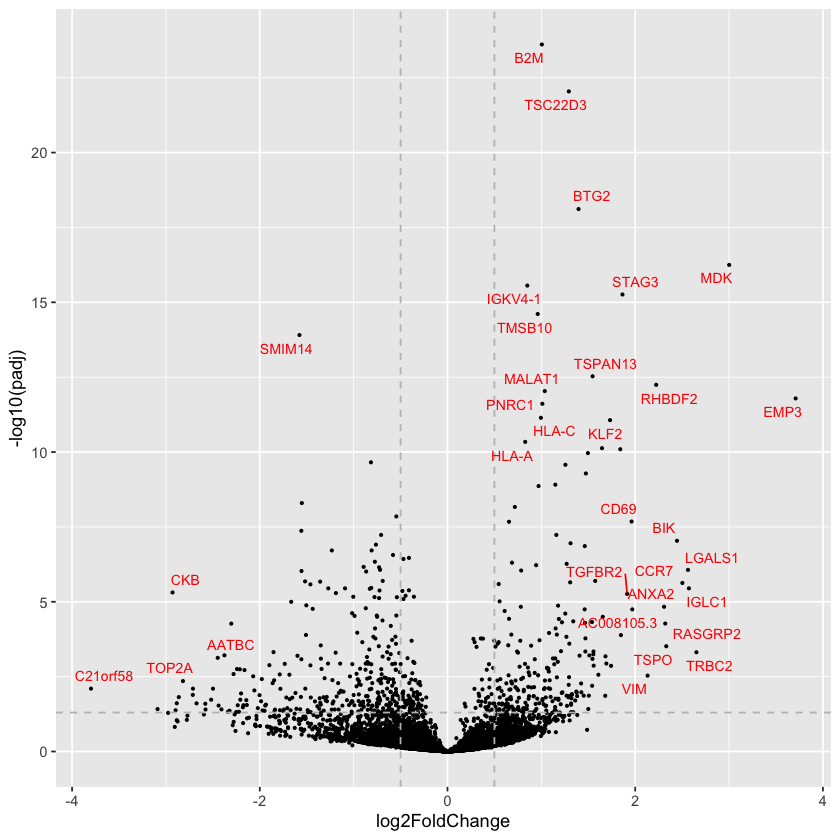

In [9]:
td <- VolcanoPlot(DE_scSHM
                  %>% filter(log2FoldChange > -1.442695e+08))
td

In [10]:
fig_save(td , filename = ("figs_paper/volcano_plot_k8"), formats = c("pdf", "png"), width = 15, height =15, units = "cm", dpi = 320)

# Pathway analysis

### Convert genes names to Entrez Gene

In [11]:
DE_scSHM$entrez = mapIds(org.Hs.eg.db,
                     keys=DE_scSHM$rowname, 
                     column="ENTREZID",
                     keytype="SYMBOL",
                     multiVals="first")
DE_scSHM$name =   mapIds(org.Hs.eg.db,
                     keys=DE_scSHM$rowname, 
                     column="GENENAME",
                     keytype="SYMBOL",
                     multiVals="first")

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns



In [12]:
## Remove any NA values (reduces the data by quite a bit)
DE_scSHM <- dplyr::filter(DE_scSHM, entrez != "NA")

## Remove any Entrez duplicates
DE_scSHM <- DE_scSHM[which(duplicated(DE_scSHM$entrez) == F), ]

In [13]:
DE_scSHM %>% filter(rowname == "AICDA")

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,entrez,name
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
AICDA,0.1431849,0.6174611,NA,2.235512,0.1349591,0.4277203,57379,activation induced cytidine deaminase


### List of DNA repair genes

In [14]:
filename <- "input/names_genes_dna_repair.csv"
genes_names <- read.csv(filename)

In [15]:
# number of genes analysed
length(genes_names$gene)

[1] 66

In [16]:
DE_scSHM %>% filter(rowname %in% genes_names$gene, padj < 0.05)  %>% arrange(rowname) 

rowname,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,entrez,name
<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
HMGB1,10.8844227,-0.6902010,NA,32.423716,1.338387e-08,2.009769e-06,3146,high mobility group box 1
HMGB2,2.8418493,-1.2728147,NA,17.757242,2.570885e-05,1.155980e-03,3148,high mobility group box 2
NUDT1,0.6821839,-0.6979036,NA,8.389475,3.796643e-03,4.851852e-02,4521,nudix hydrolase 1
PARP1,3.7821790,-0.3074080,NA,10.181118,1.431000e-03,2.471418e-02,142,poly(ADP-ribose) polymerase 1
PNKP,0.5584649,-0.8292098,NA,12.928922,3.278657e-04,8.417840e-03,11284,polynucleotide kinase 3'-phosphatase
POLD4,7.7509221,-0.8154544,NA,52.393530,5.520484e-13,2.202397e-10,57804,"DNA polymerase delta 4, accessory subunit"
RFC3,0.3175249,-1.1810120,NA,11.584628,6.722235e-04,1.453570e-02,5983,replication factor C subunit 3


## 1) Generally Applicable Gene-set Enrichment for Pathway Analysis: gage

In [17]:
kegg.sets.hs = kegg.sets.hs[sigmet.idx.hs]

In [18]:
## Extract the foldchanges
foldchanges = DE_scSHM$log2FoldChange

## Name each fold change with the corresponding Entrez ID
names(foldchanges) = DE_scSHM$entrez
head(foldchanges)

26155       51150      118424       54973       80772       54998 
-0.34678873  0.44907398  0.06748425  0.18794664  0.89244793 -0.18614535

In [19]:
## Sort fold changes in decreasing order
foldchanges <- sort(foldchanges, decreasing = TRUE)

In [20]:
#saveRDS(foldchanges, file = "foldchanges_v2.rds")

In [21]:
# Get the results
keggres = gage(foldchanges, gsets=kegg.sets.hs, same.dir=TRUE)

# Look at both up (greater), down (less), and statatistics.
lapply(keggres, head,12)

,p.geomean,stat.mean,p.val,q.val,set.size,exp1
hsa04141 Protein processing in endoplasmic reticulum,0.3737077,0.3227234,0.3737077,0.4695606,133,0.3737077
hsa03013 RNA transport,0.3746323,0.3202875,0.3746323,0.4695606,131,0.3746323
hsa04010 MAPK signaling pathway,0.3788924,0.3090897,0.3788924,0.4695606,122,0.3788924
hsa03040 Spliceosome,0.3793764,0.3078202,0.3793764,0.4695606,121,0.3793764
hsa04120 Ubiquitin mediated proteolysis,0.3833293,0.2974701,0.3833293,0.4695606,113,0.3833293
hsa04144 Endocytosis,0.3853631,0.2921581,0.3853631,0.4695606,109,0.3853631
hsa00190 Oxidative phosphorylation,0.3895568,0.2812321,0.3895568,0.4695606,101,0.3895568
hsa04110 Cell cycle,0.3895570,0.2812315,0.3895570,0.4695606,101,0.3895570
hsa04810 Regulation of actin cytoskeleton,0.3956284,0.2654759,0.3956284,0.4695606,90,0.3956284
hsa04722 Neurotrophin signaling pathway,0.3997026,0.2549434,0.3997026,0.4695606,83,0.3997026


In [22]:
# Get the pathways
keggrespathways = data.frame(id=rownames(keggres$greater), keggres$greater) %>% 
  tbl_df() %>% 
  filter(row_number()<=5) %>% 
  .$id %>% 
  as.character()
keggrespathways

[1] "hsa04141 Protein processing in endoplasmic reticulum"
[2] "hsa03013 RNA transport"                              
[3] "hsa04010 MAPK signaling pathway"                     
[4] "hsa03040 Spliceosome"                                
[5] "hsa04120 Ubiquitin mediated proteolysis"

In [23]:
# Get the IDs.
keggresids = substr(keggrespathways, start=1, stop=8)
keggresids

[1] "hsa04141" "hsa03013" "hsa04010" "hsa03040" "hsa04120"